In [4]:
import distutils.util
import os
import pickle

%env MUJOCO_GL=glfw
%env PYOPENGL_PLATFORM=glx
%env LIBGL_ALWAYS_SOFTWARE=0

try:
  print('Checking that the installation succeeded:')
  import mujoco
  mujoco.MjModel.from_xml_string('<mujoco/>')
except Exception as e:
  raise e from RuntimeError(
      'Something went wrong during installation. Check the shell output above '
      'for more information.\n'
      'If using a hosted Colab runtime, make sure you enable GPU acceleration '
      'by going to the Runtime menu and selecting "Choose runtime type".')

print('Installation successful.')

# Other imports and helper functions
import mujoco.viewer
import time
import itertools
import numpy as np
import pandas as pd
import datetime
from sklearn.metrics import r2_score
import logging

# Graphics and plotting.
import mediapy as media
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R 
from pytransform3d import rotations as pr
from pytransform3d import transformations as pt
from pytransform3d.transform_manager import TransformManager
from pytransform3d import plot_utils as pu


# More legible printing from numpy.
np.set_printoptions(precision=3, suppress=True, linewidth=100)
import pygments
print_style = 'lovelace'

from IPython.display import clear_output, Audio, HTML, display
clear_output()

# import from other python files
# from pend_utils import pd_control
import splineconverter
from caneEditor import CaneEditor

from simple_pid import PID


BRANCH_STIFFNESS = 295

tm = TransformManager()

In [5]:
# ----------------------------------------------------------------
# Functions that could probably get moved to another file
# ----------------------------------------------------------------

def flip_segs_from_curve(segs, print_output=False):
    # Switch coordinate frames from spline (camera) to MuJoCo and center at origin
    trans_segs = np.zeros_like(segs)
    trans_segs[:,0] = segs[:,2].copy()-segs[-1,2]  # +x in mujoco is +z in camera ("forwards")
    trans_segs[:,1] = -segs[:,0].copy()+segs[-1,0]  # +y in mujoco is -x in camera ("left")
    trans_segs[:,2] = -segs[:,1].copy()+segs[-1,1]  # +z in mujoco is -y in camera ("up") (y was down in camera)
    segs_flipped = trans_segs[::-1]
    if print_output:
        print(segs_flipped)
    return segs_flipped
    
def get_midpoints(segs, print_output=False):
    midpoint_zs = []
    for i in range(len(segs)-1):
        midpoint = (segs[i] + segs[i+1]) / 2
        midpoint_zs.append(midpoint[2])
    midpoint_zs = np.array(midpoint_zs)
    if print_output:
        print(midpoint_zs)
    return midpoint_zs


In [18]:
BUSH_NUM = 14
BRANCH_NUM = 3
TRIAL_NUM = 2

Initial segment endpoints:
[[  0.   0.   0.]
 [101. 651. 310.]]
RMSE between the B-spline curve and the baseline segments before segmenting: 47.739
RMSE between the discretized segments and the curve after segmenting: 0.333
[[ 0.     0.     0.   ]
 [-0.07   0.006  0.253]
 [-0.086  0.01   0.3  ]
 [-0.112  0.017  0.36 ]
 [-0.122  0.02   0.38 ]
 [-0.139  0.026  0.41 ]
 [-0.153  0.031  0.433]
 [-0.166  0.037  0.453]
 [-0.205  0.055  0.508]
 [-0.225  0.064  0.534]
 [-0.26   0.079  0.581]
 [-0.285  0.091  0.617]
 [-0.31   0.101  0.651]]
[0.127 0.277 0.33  0.37  0.395 0.422 0.443 0.481 0.521 0.557 0.599 0.634]


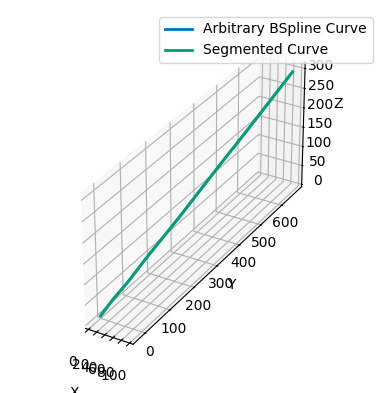

In [19]:
# ----------------------------------------------------------------
# Load in the curve
# ----------------------------------------------------------------
if BUSH_NUM == 9 and BRANCH_NUM == 2:
    strictly_increasing = False
else:
    strictly_increasing = True
segs_mm, RMSE = splineconverter.segment_curve_from_cloudcompare('../data/ccCurves/B' + str(BUSH_NUM) + '_branch' + str(BRANCH_NUM) + '_smoothpolyline_minbb.txt', 
                                                    make_plot=True, strictly_increasing=strictly_increasing)
segs_cc = np.array(segs_mm) / 1000  # convert to meters from millimeters
diamdata = pd.read_csv('../data/diameters/offset_branch_diameter_data.csv')
diameter_data_df = pd.DataFrame(diamdata, columns=['Bush', 'Branch', 'Location', 'Diameter', 'Height'])

 # ----------------------------------------------------------------
# Process the curve data into segments
# ----------------------------------------------------------------
# Correctly orient the segments for MuJoCo (they're upside down from the camera)
segs_flipped = flip_segs_from_curve(segs_cc, print_output=True)
# splineconverter.plot_obj_file('../data/splines/B3_take2/bush_1_0.obj')
# print(segs_flipped)

# get the z-value of the midpoints of each segment
midpoint_zs = get_midpoints(segs_flipped, print_output=True)

# Get lengths of segments and angles between them (for setting up the MJCF model) 
seg_lengths = splineconverter.get_segment_lengths(segs_flipped)
seg_angles = splineconverter.get_angles_between_segments(segs_flipped) 

In [20]:
# ----------------------------------------------------------------
# Pull relevant data for this cane and trial
# ----------------------------------------------------------------
# Get the diameter data for this particular cane (bush, branch number)
this_cane_data = diameter_data_df.query('Bush == ' + str(BUSH_NUM) + ' and Branch == ' + str(BRANCH_NUM))
print(this_cane_data)

# generate a linear fit for the diameters 
this_cane_linearfit = np.polyfit(this_cane_data['Height'], this_cane_data['Diameter'], 1)
def get_rad_at_height(height_in_m):
    diameter = this_cane_linearfit[0]*(height_in_m*1000) + this_cane_linearfit[1] #convert m to mm
    return diameter/2/1000.  # convert mm to m

# Get the radii at the segment midpoints using the linear fit
radii = get_rad_at_height(midpoint_zs)
print("Radii at segment midpoints (m): ", radii) 

# get the probe height for this trial (convert from mm to m)
PROBE_HEIGHT = this_cane_data.query('Location == ' +str(TRIAL_NUM))['Height'].values[0]/1000  # convert mm to m
print("Probe height (m): ", PROBE_HEIGHT)

# ----------------------------------------------------------------
# Load in the push data for this trial
# ----------------------------------------------------------------

# import forces from csv
filename = "bush_" + str(BUSH_NUM) + "_branch_" + str(BRANCH_NUM) + "_trial_" + str(TRIAL_NUM) + ".csv"
pushdata = pd.read_csv('../data/cropped_push_data/' + filename)
TRIAL_LENGTH = pushdata.shape[0]
print(f"Loaded push data from {filename} with {TRIAL_LENGTH} rows.")


    Bush  Branch  Location  Diameter  Height
42    14       3         1      16.1     814
43    14       3         2      18.0     629
44    14       3         3      22.6     442
Radii at segment midpoints (m):  [0.014 0.013 0.012 0.012 0.011 0.011 0.011 0.011 0.01  0.01  0.01  0.009]
Probe height (m):  0.629
Loaded push data from bush_14_branch_3_trial_2.csv with 50 rows.


Last site before probe height is 11 with position [-0.285  0.091  0.617]
distance along branch to probe site: 0.007 m


""

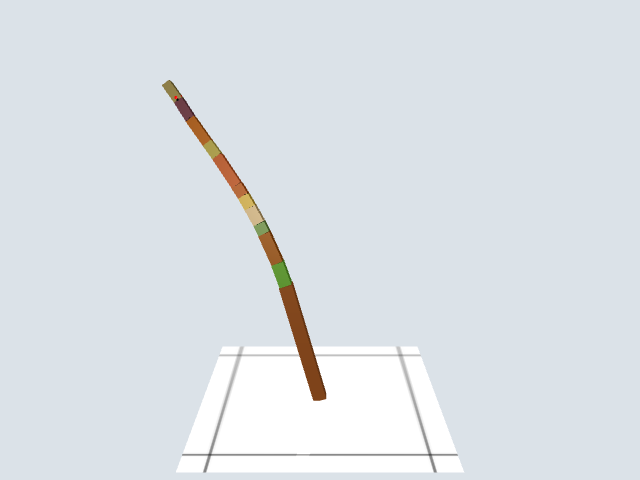

In [ ]:
# ----------------------------------------------------------------
# Build the MuJoCo model
# ----------------------------------------------------------------
# read in the base XML for the branch model (this has the world and the probe, but not the segments of the branch yet)
with open('../urdf/branch_base.xml', 'r') as f:
    branch_xml = f.read()

flex_modulus = 4.9e9  # Flexural modulus from average of 6 tested canes
editor = CaneEditor(branch_xml, flex_mod=flex_modulus)

# BUILD THE CANE MODEL IN MJCF
editor.build_branch_from_lengths(seg_lengths, radii, def_stiff=BRANCH_STIFFNESS, verbose=False)
editor.offset_all_joints_in_direction('x', seg_angles[:,0])
editor.offset_all_joints_in_direction('y', seg_angles[:,1])
zero_pos = editor.get_zero_springref_pos()
editor.total_length = segs_flipped[-1][2]
# print("Total length of branch (m): ", editor.total_length)
# print("Probe height (m): ", PROBE_HEIGHT)
editor.define_probe_site(PROBE_HEIGHT, zero_pos, verbose=False)
editor.show_model_at_pos(zero_pos)
# editor.show_model_at_pos_with_camera(zero_pos, 1)

# save a picture of the mujoco rendering to images/mujocoRenders
# filename = '../images/mujocoRenders/' + time_now_str + '_bush' + str(BUSH_NUM) + '_branch'+ str(BRANCH_NUM) + '_trial' + str(TRIAL_NUM) + '_' + str(len(segs)-1) + 'segs' + '.pdf'
# if RECORDING_DATA:
#     editor.save_picture_of_model(zero_pos, filename)


In [22]:
# ----------------------------------------------------------------
# Initialize the simulation
# ----------------------------------------------------------------

model = editor.model
data = mujoco.MjData(model)
data.qpos[:] = zero_pos
mujoco.mj_forward(model, data)

model.opt.integrator = mujoco.mjtIntegrator.mjINT_IMPLICIT
model.opt.solver = mujoco.mjtSolver.mjSOL_NEWTON 
model.opt.timestep = 0.00002  # seconds
model.opt.tolerance = 1e-8

FRAMERATE = 60 
DURATION = 3 #TRIAL_LENGTH 
DATACAP_RATE = 100 # Hz, how often to record data from the simulation (in Hz)

timevals = []
posvals = []
velvals = []
forcevals = []
probevals = []
frames_stepped = []

pre_control_timevals = []
pre_control_forcevals = []
pre_control_posvals = []
pre_control_probeposes = []

# -- Displacement controller setup --
probe_site_id = model.site("probe_contact_site").id
probe_body_id = int(model.site_bodyid[probe_site_id])
probe_init_xpos = data.site_xpos[probe_site_id].copy()

# Tune these gains as needed
pid = PID(Kp=150, Ki=22, Kd=10, setpoint=0)
pid.output_limits = (-10, 50)  # force limits in Newtons

pid.setpoint = 0 # mm, total displacement
CTRL_POS_UPDATE_RATE = 1 # Hz, how often to update the control position
last_force = 0.0
print("Starting simulation...")

with mujoco.Renderer(model, width=640, height=480) as renderer:
    while data.time < DURATION:
        # -- measure current x-displacement of probe contact site --
        current_disp_m = data.site_xpos[probe_site_id][0] - probe_init_xpos[0]

        # -- PID: drive current displacement toward target --
        force_x = last_force + pid(current_disp_m)

        # -- apply force at probe contact site --
        data.qfrc_applied[:] = 0
        mujoco.mj_applyFT(model, data,
                          np.array([force_x, 0.0, 0.0]),  # force [N]
                          np.zeros(3),                     # torque
                          data.site_xpos[probe_site_id],  # point of application (world frame)
                          probe_body_id,
                          data.qfrc_applied)

        # step the simulation
        mujoco.mj_step(model, data)

        # -- save data from sim  -- 
        if len(timevals) < data.time * DATACAP_RATE:
            timevals.append(data.time)
            posvals.append(data.qpos.copy())
            velvals.append(data.qvel.copy())
            forcevals.append(force_x)
            probevals.append(current_disp_m)
        
        # -- render the scene and save it --
        if len(frames_stepped) < data.time * FRAMERATE:
            renderer.update_scene(data)
            pixels = renderer.render()
            frames_stepped.append(pixels)

        # update the control position at the specified rate
        if int(data.time * CTRL_POS_UPDATE_RATE) > int((data.time - model.opt.timestep) * CTRL_POS_UPDATE_RATE):
            pre_control_timevals.append(data.time)
            pre_control_forcevals.append(force_x)
            pre_control_posvals.append(data.qpos.copy())
            pre_control_probeposes.append(current_disp_m)
            last_force = force_x
            print(f"Time: {data.time:.3f}s, Current Displacement: {current_disp_m*1000:.3f} mm, Force Applied: {force_x:.3f} N")
            pid.setpoint += 0.0005  # increment by 0.5 mm (0.0005 m)
            
media.show_video(frames_stepped, fps=FRAMERATE)


Starting simulation...
Time: 1.000s, Current Displacement: -0.017 mm, Force Applied: 0.004 N
Time: 2.000s, Current Displacement: 0.026 mm, Force Applied: 0.127 N
Time: 3.000s, Current Displacement: 0.122 mm, Force Applied: 0.401 N


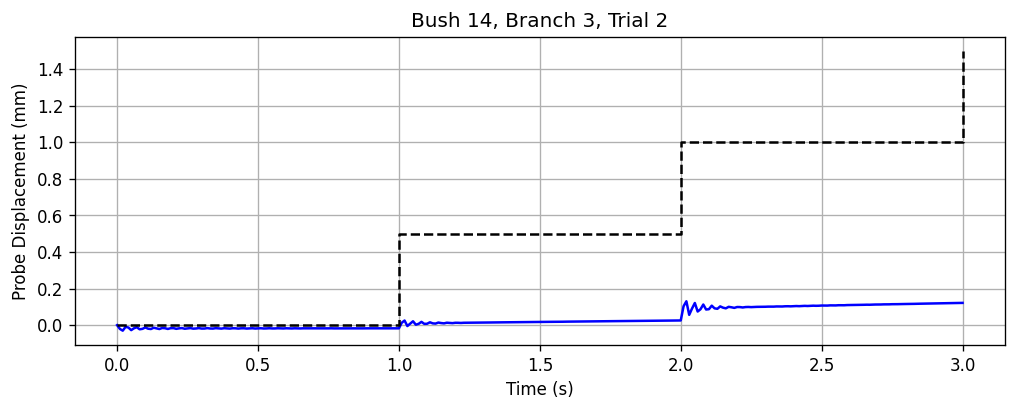

In [23]:
dpi=120 
width=1200 
height=400
figsize=(width/dpi, height/dpi)
fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

probearray = np.array(probevals)*1000  # convert from m to mm for easier comparison to push data
ax.plot(timevals, probearray, label='Simulation Probe Displacement', color='blue')
ax.set_title(f'Bush {BUSH_NUM}, Branch {BRANCH_NUM}, Trial {TRIAL_NUM}')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Probe Displacement (mm)')

# Add a reference line that steps up by 0.001 every 1 second
step_height = 0.5
step_interval = 1.0
step_times = np.arange(0, timevals[-1]+step_interval, step_interval)
step_values = np.arange(0, step_height*len(step_times), step_height)
# Interpolate to match the timevals for plotting as a step function
step_ref = np.zeros_like(timevals)
for i, t in enumerate(timevals):
    idx = np.searchsorted(step_times, t, side='right')
    step_ref[i] = step_values[idx-1] 
ax.step(timevals, step_ref, where='post', linestyle='--', color='black', label='0.001 step every 1s')
# ax.legend()
ax.grid(True)

In [ ]:
# Convert lists to numpy arrays for easier manipulation
pre_control_posvals_array = np.array(pre_control_posvals)*1000  # convert from m to mm for easier comparison to push data
pre_control_timevals_array = np.array(pre_control_timevals)
pre_control_forcevals_array = np.array(pre_control_forcevals)
pre_control_probeposes_array = np.array(pre_control_probeposes)*1000  # convert from m to mm for easier comparison to push data

sim_data_df = pd.DataFrame({
    'Time (s)': pre_control_timevals_array,
    'Probe (mm)': pre_control_probeposes_array,
    'Force (N)': pre_control_forcevals_array
})



NameError: name 'sim_data_df' is not defined

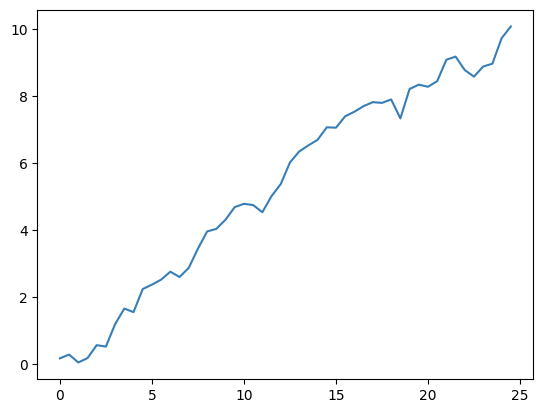

In [24]:
fig = plt.figure()
plt.plot(pushdata['Displacement (mm)'], pushdata['Load (N)'], label='Measured Data', color='#377eb8')
# plt.plot(pushdata['Displacement (mm)'], get_force_at_disp(pushdata['Displacement (mm)']), label='Linear Fit', linestyle='--', color='#ff7f00')
plt.plot(sim_data_df['Probe (mm)'], sim_data_df['Force (N)'], label='Simulator probe', linestyle='-', color='#4daf4a')
# plt.plot(pre_control_posvals_array, get_sim_force_at_disp(pre_control_posvals_array), label='Simulator Linear Fit', linestyle='--', color='#f781bf')
# plt.scatter(pushdata['Displacement (mm)'].iloc[[20, 30, 40]], pushdata['Load (N)'].iloc[[20, 30, 40]], color='blue')
# plt.scatter(pre_control_posvals*1000, pre_control_forcevals, color='orange', s=10)
plt.xlabel("Displacement (mm)")
plt.ylabel("Load (N)")
plt.legend()
plt.grid()